<a href="https://colab.research.google.com/github/Nojhi3/tooth-segmentation/blob/main/Unet_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!git clone https://github.com/SerdarHelli/Segmentation-of-Teeth-in-Panoramic-X-ray-Image-Using-U-Net.git

fatal: destination path 'Segmentation-of-Teeth-in-Panoramic-X-ray-Image-Using-U-Net' already exists and is not an empty directory.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#take a look at the kind of GPU we have
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
import sys
sys.path.append("/content/Segmentation-of-Teeth-in-Panoramic-X-ray-Image")

In [ ]:
%cd /content/Segmentation-of-Teeth-in-Panoramic-X-ray-Image-Using-U-Net
#!pip install -qr requirements.txt
#You can  use pip install however colab includes all libraries so we dont need them

/content/Segmentation-of-Teeth-in-Panoramic-X-ray-Image-Using-U-Net


In [ ]:
from download_dataset import *
import os
path = "/content/Data"
if os.path.exists(path+'/DentalPanoramicXrays.zip') == False:
  os.mkdir(path)
  download_dataset(path+'/')

Downloading...
Completed...


In [ ]:
!pip install natsort

In [ ]:
from images_prepare import *
#pre_images(resize_shape,path,include_zip)
X,X_sizes=pre_images((512,512),path,True)

In [ ]:
from masks_prepare import *
#Y=pre_masks(resize_shape=(512,512),path='/content/Segmentation-of-Teeth-in-Panoramic-X-ray-Image/Original_Masks')  ORIGINALL MASKS function
Y=pre_splitted_masks(path='/content/Segmentation-of-Teeth-in-Panoramic-X-ray-Image-Using-U-Net/Custom_Masks') #Custom Splitted MASKS size 512x512


In [ ]:
X=np.float32(X/255)
Y=np.float32(Y/255)

In [ ]:
x_train=X[:105,:,:,:]
y_train=Y[:105,:,:,:]
x_test=X[105:,:,:,:]
y_test=Y[105:,:,:,:]

In [ ]:
!pip uninstall opencv-python-headless==4.5.5.62

Found existing installation: opencv-python-headless 4.11.0.86
Uninstalling opencv-python-headless-4.11.0.86:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/cv2/*
    /usr/local/lib/python3.11/dist-packages/opencv_python_headless-4.11.0.86.dist-info/*
    /usr/local/lib/python3.11/dist-packages/opencv_python_headless.libs/libavcodec-76c43bf0.so.59.37.100
    /usr/local/lib/python3.11/dist-packages/opencv_python_headless.libs/libavformat-d296e685.so.59.27.100
    /usr/local/lib/python3.11/dist-packages/opencv_python_headless.libs/libavutil-734d06dd.so.57.28.100
    /usr/local/lib/python3.11/dist-packages/opencv_python_headless.libs/libcrypto-8c1ab3ad.so.1.1
    /usr/local/lib/python3.11/dist-packages/opencv_python_headless.libs/libgfortran-91cc3cb1.so.3.0.0
    /usr/local/lib/python3.11/dist-packages/opencv_python_headless.libs/libopenblas-r0-f650aae0.3.3.so
    /usr/local/lib/python3.11/dist-packages/opencv_python_headless.libs/libpng16-ef62451c.so.16.44.0
    /usr/local/li

In [ ]:
!pip install opencv-python-headless
!pip install albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 10.5 MB/s eta 0:00:00


In [ ]:
!pip install opencv-python-headless==4.5.3.56


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 8.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import cv2

import albumentations as A
#Augmention . Change what you want ! Care about Your GPU and CPU RAM

#If you get error : cannot import name '_registerMatType' from 'cv2.cv2' :
#!pip uninstall opencv-python-headless==4.5.5.62
#!pip install opencv-python-headless==4.5.2.52

aug = A.Compose([
    A.OneOf([A.RandomCrop(width=512, height=512),
                 A.PadIfNeeded(min_height=512, min_width=512, p=0.5)],p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25,p=0.5),
    A.Compose([A.RandomScale(scale_limit=(-0.15, 0.15), p=1, interpolation=1),
                            A.PadIfNeeded(512, 512, border_mode=cv2.BORDER_CONSTANT),
                            A.Resize(512, 512, cv2.INTER_NEAREST), ],p=0.5),
    A.ShiftScaleRotate (shift_limit=0.325, scale_limit=0.15, rotate_limit=15,border_mode=cv2.BORDER_CONSTANT, p=1),
    A.Rotate(15,p=0.5),
    A.Blur(blur_limit=1, p=0.5),
    A.Downscale(scale_min=0.15, scale_max=0.25,  always_apply=False, p=0.5),
    A.GaussNoise(var_limit=(0.05, 0.1), mean=0, per_channel=True, always_apply=False, p=0.5),
    A.HorizontalFlip(p=0.25),
])

x_train1=np.copy(x_train)
y_train1=np.copy(y_train)
count=0
while(count<4):
  x_aug2=np.copy(x_train1)
  y_aug2=np.copy(y_train1)
  for i in range(len(x_train1)):
    augmented=aug(image=x_train1[i,:,:,:],mask=y_train1[i,:,:,:])
    x_aug2[i,:,:,:]= augmented['image']
    y_aug2[i,:,:,:]= augmented['mask']
  x_train=np.concatenate((x_train,x_aug2))
  y_train=np.concatenate((y_train,y_aug2))
  if count == 9:
    break
  count += 1

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.11/dist-packages/albumentations/augmentations/blur/functional.py:147: UserWarning: blur_limit: Invalid kernel size range (3, 1). Values less than 3 are not allowed. Range automatically adjusted to (3, 3).
  result = _ensure_min_value(result, min_value, info.field_name)
<ipython-input-15-e6ab24f7052e>:20: UserWarning: Argument(s) 'scale_min, scale_max, always_apply' are not valid for transform Downscale
  A.Downscale(scale_min=0.15, scale_max=0.25,  always_apply=False, p=0.5),
<ipython-input-15-e6ab24f7052e>:21: UserWarning: Argument(s) 'var_limit, mean, always_apply' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(0.05, 0.1), mean=0, per_channel=True, always_apply=False, p=0.5),


In [ ]:
#For Relase unneccasery memory
del x_aug2
del X
del Y
del y_aug2
del y_train1
del x_train1
del augmented

In [ ]:
import random
import matplotlib.pyplot as plt
random_number=random.randint(0,104)
print(random_number)

77


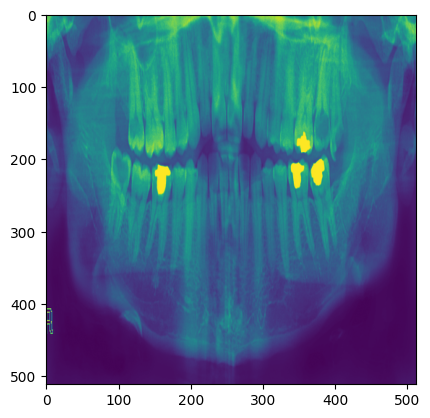

In [ ]:
#Checking data X  and Y matching
plt.imshow(x_train[random_number,:,:,0])

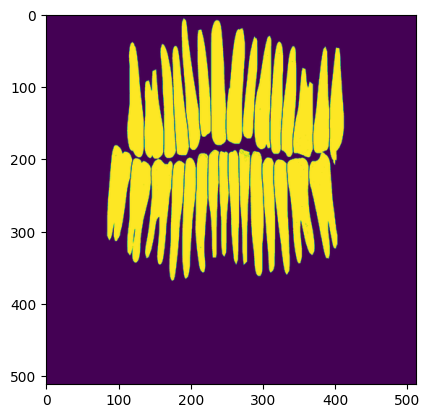

In [ ]:
#Checking data X  and Y matching
plt.imshow(y_train[random_number,:,:,0])

In [ ]:
from model import *
model=UNET(input_shape=(512,512,1),last_activation='sigmoid')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512, 512,  │          0 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256,  │          0 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     36,928 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    147,584 │ dropout_2[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_2[

 Total params: 13,423,361 (51.21 MB)

 Trainable params: 13,420,481 (51.20 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [ ]:
model.compile(optimizer ='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
#Your choice batch and epoch
model.fit(x_train,y_train,batch_size=32,epochs=100,verbose=1)

Epoch 1/200
 1/66 ━━━━━━━━━━━━━━━━━━━━ 2:22:06 131s/step - accuracy: 0.3247 - loss: 0.7645

In [ ]:
predict_img=model.predict(x_test)
##model.save(path)
predict=predict_img[1,:,:,0]

In [ ]:
#Example Test
from sklearn.metrics import f1_score
import numpy as np
predict_img1=(predict_img>0.25)*1
y_test1=(y_test>0.25)*1

f1_score(predict_img1.flatten(), y_test1.flatten(), average='micro')

In [ ]:

plt.figure(figsize = (20,10))
plt.title("Predict Mask",fontsize = 40)
plt.imshow(predict)
#For CCA, we saved
plt.imsave("/content/predict.png",predict)

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np  # Ensure numpy is imported
from CCA_Analysis import *

## Plotting - RESULT Example
img = cv2.imread("/content/Data/Images/107.png")  # Original img 107.png

# Ensure predict is defined before use (assuming it comes from CCA_Analysis or another part of the code)
predict1 = cv2.resize(predict, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LANCZOS4)

# Convert prediction to binary mask
mask = np.uint8(predict1 * 255)
_, mask = cv2.threshold(mask, thresh=255 / 2, maxval=255, type=cv2.THRESH_BINARY)

# Find contours
cnts, hierarchy = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Convert image to 3-channel if needed
if len(img.shape) == 2 or img.shape[2] == 1:
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw contours
img = cv2.drawContours(img, cnts, -1, (255, 0, 0), 2)

# Display the result
cv2_imshow(img)

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
from CCA_Analysis import *


##Plotting - RESULT Example with CCA_Analysis
img=cv2.imread("/content/Data/Images/108.png")#original img 107.png

#load image (mask was saved by matplotlib.pyplot)
predicted=cv2.imread("/content/predict.png")

predicted = cv2.resize(predicted, (img.shape[1],img.shape[0]), interpolation=cv2.INTER_LANCZOS4)

cca_result,teeth_count=CCA_Analysis(img,predicted,3,2)
cv2_imshow(cca_result)

In [ ]:
print(teeth_count,"Teeth Count")

In [ ]:
import tensorflow as tf
tf.keras.models.save_model(model, '/content/drive/MyDrive/dental1.keras')

In [ ]:
from tensorflow import keras

# Load the model from Google Drive
model = keras.models.load_model('/content/drive/MyDrive/dental1.keras')


In [ ]:

from google.colab.patches import cv2_imshow
import numpy as np

img_path = '/content/opg.jpg'
# Load the image
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Check if the image loaded correctly
if img is None:
    raise FileNotFoundError(f"Error: Image not found at {img_path}. Check the file path.")

# Resize the image to match the model's expected input size
img = cv2.resize(img, (512, 512))

# Normalize pixel values
img = img / 255.0

# Add channel dimension (grayscale needs 1 channel)
img = np.expand_dims(img, axis=-1)

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Ensure correct shape before prediction
print(f"Processed image shape: {img.shape}")  # Should be (1, 512, 512, 1)

# Predict
prediction = model.predict(img)

# If it's a segmentation model, apply a threshold
mask = (prediction[0] > 0.5).astype(np.uint8) * 255

# Display the predicted mask
cv2_imshow(mask)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np  # Ensure numpy is imported
from CCA_Analysis import *  # Assuming this is where `predict` comes from

## Plotting - RESULT Example
img = cv2.imread ('/content/opg.jpg')
 # Original image

# Ensure `predict` is defined before use (assuming it comes from CCA_Analysis or another part of the code)
predict1 = cv2.resize(predict, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LANCZOS4)

# Convert prediction to binary mask
mask = np.uint8(predict1 * 255)
_, mask = cv2.threshold(mask, thresh=255 / 2, maxval=255, type=cv2.THRESH_BINARY)

# Find contours
cnts, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # Use RETR_EXTERNAL to detect separate teeth

# Convert image to 3-channel if needed
if len(img.shape) == 2 or img.shape[2] == 1:
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw bounding boxes around each detected tooth
min_area = 500  # Adjust to filter small objects (noise)
for cnt in cnts:
    if cv2.contourArea(cnt) > min_area:  # Ignore small objects (noise)
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green box for each tooth

# Display the result
cv2_imshow(img)
